In [8]:
from sklearn.datasets import load_breast_cancer

data = load_breast_cancer()

X = data.data
y = data.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (569, 30)
y shape: (569,)


In [9]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

print("train:", X_train.shape)
print("test:", X_test.shape)

train: (455, 30)
test: (114, 30)


In [10]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [11]:
import numpy as np

def sigmoid(z):
    return 1 / (1 + np.exp(-z))

def predict_prob(X, w, b):

    z = np.dot(X, w) + b
    p = sigmoid(z)

    return p

def binary_cross_entropy(y, p):

    epsilon = 1e-8

    loss = -np.mean(
        y * np.log(p + epsilon)
        + (1 - y) * np.log(1 - p + epsilon)
    )

    return loss

def compute_gradients(X, y, p):

    m = X.shape[0]

    dz = p - y

    dw = np.dot(X.T, dz) / m
    db = np.sum(dz) / m

    return dw, db

print("sigmoid(0) =", sigmoid(0))

def train(X, y, lr=0.01, epochs=1000):

    n_features = X.shape[1]

    w = np.zeros(n_features)
    b = 0

    losses = []

    for epoch in range(epochs):

        p = predict_prob(X, w, b)

        loss = binary_cross_entropy(y, p)

        dw, db = compute_gradients(X, y, p)

        w = w - lr * dw
        b = b - lr * db

        losses.append(loss)

        if epoch % 100 == 0:
            print(f"Epoch {epoch}, Loss={loss}")

    return w, b, losses

sigmoid(0) = 0.5


In [12]:
w, b, losses = train(X_train, y_train)

Epoch 0, Loss=0.6931471605599454
Epoch 100, Loss=0.25270239565138375
Epoch 200, Loss=0.19041173407908116
Epoch 300, Loss=0.162145431529488
Epoch 400, Loss=0.14538791777958612
Epoch 500, Loss=0.1340782575397816
Epoch 600, Loss=0.1258191288901464
Epoch 700, Loss=0.11945861193932991
Epoch 800, Loss=0.11436999768325895
Epoch 900, Loss=0.11018089978244827


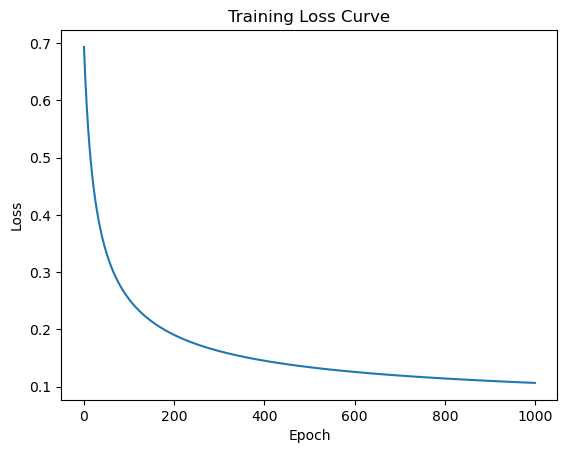

In [13]:
import matplotlib.pyplot as plt
import os

plt.plot(losses)

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss Curve")

os.makedirs(os.path.join("resources", "pics"), exist_ok=True)
plot_path = os.path.join("resources", "pics", "lab2.png")
plt.savefig(plot_path, dpi=150)

plt.show()

In [14]:
p_test = predict_prob(X_test, w, b)

# y_pred = []

# for p in p_test:
#     if p >= 0.5:
#         y_pred.append(1)
#     else:
#         y_pred.append(0)

# y_pred = np.array(y_pred)

y_pred = p_test >= 0.5

accuracy = np.mean(y_pred == y_test)

print("Test Accuracy:", accuracy)

Test Accuracy: 0.9736842105263158
